In [17]:
# Pandas Task Ashley Eshghi
import pandas
data = pandas.read_csv("Cars93_missing.csv")
print(data.head())

  Manufacturer    Model     Type  Min.Price  Price  Max.Price  MPG.city  \
0        Acura  Integra    Small       12.9   15.9       18.8      25.0   
1          NaN   Legend  Midsize       29.2   33.9       38.7      18.0   
2         Audi       90  Compact       25.9   29.1       32.3      20.0   
3         Audi      100  Midsize        NaN   37.7       44.6      19.0   
4          BMW     535i  Midsize        NaN   30.0        NaN      22.0   

   MPG.highway             AirBags DriveTrain  ... Passengers  Length  \
0         31.0                 NaN      Front  ...        5.0   177.0   
1         25.0  Driver & Passenger      Front  ...        5.0   195.0   
2         26.0         Driver only      Front  ...        5.0   180.0   
3         26.0  Driver & Passenger        NaN  ...        6.0   193.0   
4         30.0                 NaN       Rear  ...        4.0   186.0   

   Wheelbase  Width  Turn.circle Rear.seat.room  Luggage.room  Weight  \
0      102.0   68.0         37.0     

In [18]:
data = pandas.read_csv("Cars93_missing.csv")
object_series = data["Model"]
data.index = object_series
print(data.head())

        Manufacturer    Model     Type  Min.Price  Price  Max.Price  MPG.city  \
Model                                                                           
Integra        Acura  Integra    Small       12.9   15.9       18.8      25.0   
Legend           NaN   Legend  Midsize       29.2   33.9       38.7      18.0   
90              Audi       90  Compact       25.9   29.1       32.3      20.0   
100             Audi      100  Midsize        NaN   37.7       44.6      19.0   
535i             BMW     535i  Midsize        NaN   30.0        NaN      22.0   

         MPG.highway             AirBags DriveTrain  ... Passengers  Length  \
Model                                                ...                      
Integra         31.0                 NaN      Front  ...        5.0   177.0   
Legend          25.0  Driver & Passenger      Front  ...        5.0   195.0   
90              26.0         Driver only      Front  ...        5.0   180.0   
100             26.0  Driver & Passen

In [19]:
data = pandas.read_csv("Cars93_missing.csv")
data.loc[data["Origin"] == "USA", "Origin"] = "United States"
print(data[["Model", "Origin"]].head(10))

        Model         Origin
0     Integra        non-USA
1      Legend        non-USA
2          90        non-USA
3         100        non-USA
4        535i        non-USA
5     Century  United States
6     LeSabre  United States
7  Roadmaster  United States
8     Riviera  United States
9     DeVille  United States


In [20]:
data = pandas.read_csv("Cars93_missing.csv")
print("Column names:")
print(data.columns)
print("Missing values in each column:")
print(data.isnull().sum())
print("Total missing values:")
print(data.isnull().sum().sum())

Column names:
Index(['Manufacturer', 'Model', 'Type', 'Min.Price', 'Price', 'Max.Price',
       'MPG.city', 'MPG.highway', 'AirBags', 'DriveTrain', 'Cylinders',
       'EngineSize', 'Horsepower', 'RPM', 'Rev.per.mile', 'Man.trans.avail',
       'Fuel.tank.capacity', 'Passengers', 'Length', 'Wheelbase', 'Width',
       'Turn.circle', 'Rear.seat.room', 'Luggage.room', 'Weight', 'Origin',
       'Make'],
      dtype='object')
Missing values in each column:
Manufacturer           4
Model                  1
Type                   3
Min.Price              7
Price                  2
Max.Price              5
MPG.city               9
MPG.highway            2
AirBags               38
DriveTrain             7
Cylinders              5
EngineSize             2
Horsepower             7
RPM                    3
Rev.per.mile           6
Man.trans.avail        5
Fuel.tank.capacity     8
Passengers             2
Length                 4
Wheelbase              1
Width                  6
Turn.circle      

In [21]:
def exchange_columns(dataframe, column1, column2):
    columns = list(dataframe.columns)
    position1 = columns.index(column1)
    position2 = columns.index(column2)
    columns[position1], columns[position2] = columns[position2], columns[position1]
    return dataframe[columns]
data = exchange_columns(data, "Manufacturer", "Model")
print("After exchanging columns:")
print(data.head())
data = data[sorted(data.columns)]
print("\nColumns sorted by name:")
print(data.columns)

After exchanging columns:
     Model Manufacturer     Type  Min.Price  Price  Max.Price  MPG.city  \
0  Integra        Acura    Small       12.9   15.9       18.8      25.0   
1   Legend          NaN  Midsize       29.2   33.9       38.7      18.0   
2       90         Audi  Compact       25.9   29.1       32.3      20.0   
3      100         Audi  Midsize        NaN   37.7       44.6      19.0   
4     535i          BMW  Midsize        NaN   30.0        NaN      22.0   

   MPG.highway             AirBags DriveTrain  ... Passengers  Length  \
0         31.0                 NaN      Front  ...        5.0   177.0   
1         25.0  Driver & Passenger      Front  ...        5.0   195.0   
2         26.0         Driver only      Front  ...        5.0   180.0   
3         26.0  Driver & Passenger        NaN  ...        6.0   193.0   
4         30.0                 NaN       Rear  ...        4.0   186.0   

   Wheelbase  Width  Turn.circle Rear.seat.room  Luggage.room  Weight  \
0      102.

In [22]:
data2 = data.dropna(subset=["Price"])
lower = data2["Price"].quantile(0.05)
upper = data2["Price"].quantile(0.95)
result = data2[
    (data2["Price"] >= lower) &
    (data2["Price"] <= upper)
]

print("Lower 5% limit:", lower)
print("Upper 5% limit:", upper)
print(result)

Lower 5% limit: 8.5
Upper 5% limit: 36.900000000000006
               AirBags Cylinders DriveTrain  EngineSize  Fuel.tank.capacity  \
0                  NaN         4      Front         1.8                13.2   
1   Driver & Passenger         6      Front         3.2                18.0   
2          Driver only         6      Front         2.8                16.9   
4                  NaN         4       Rear         3.5                21.1   
5          Driver only         4        NaN         2.2                16.4   
..                 ...       ...        ...         ...                 ...   
88                 NaN         5      Front         2.5                21.1   
89                 NaN         4      Front         2.0                18.5   
90                 NaN         6      Front         2.8                18.5   
91         Driver only       NaN       Rear         2.3                15.8   
92  Driver & Passenger         5      Front         2.4                19.3 

In [23]:
average = data["Price"].mean()
print("Average:", average)
data["Price"] = data["Price"].fillna(average)
print(data["Price"])

Average: 19.61648351648352
0     15.9
1     33.9
2     29.1
3     37.7
4     30.0
      ... 
88    19.7
89    20.0
90    23.3
91    22.7
92    26.7
Name: Price, Length: 93, dtype: float64


In [24]:
dictionary1 = {
    "ID": [1, 2, 3],
    "Name": ["Anna", "John", "Peter"]
}
dictionary2 = {
    "ID": [1, 2, 3],
    "Score": [85, 92, 78]
}
dataframe1 = pandas.DataFrame(dictionary1)
dataframe2 = pandas.DataFrame(dictionary2)
print("First DataFrame:")
print(dataframe1)
print("Second DataFrame:")
print(dataframe2)
merged = pandas.merge(dataframe1, dataframe2, on="ID")
print("Merged DataFrame:")
print(merged)

First DataFrame:
   ID   Name
0   1   Anna
1   2   John
2   3  Peter
Second DataFrame:
   ID  Score
0   1     85
1   2     92
2   3     78
Merged DataFrame:
   ID   Name  Score
0   1   Anna     85
1   2   John     92
2   3  Peter     78


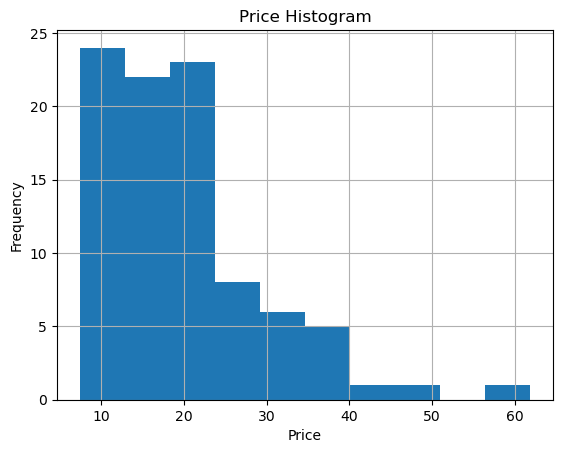

In [25]:
import pandas
import matplotlib.pyplot
data = pandas.read_csv("Cars93_missing.csv")
data["Price"].dropna().hist()
matplotlib.pyplot.title("Price Histogram")
matplotlib.pyplot.xlabel("Price")
matplotlib.pyplot.ylabel("Frequency")
matplotlib.pyplot.show()